In [116]:
import pandas as pd
from matplotlib import pyplot as plt


In [6]:
SM_csv = './data/SM_AirBnB.csv'
SM_Airbnb_df = pd.read_csv(SM_csv)
SM_Airbnb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3516 entries, 0 to 3515
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              3516 non-null   float64
 1   name                            3516 non-null   object 
 2   host_id                         3516 non-null   int64  
 3   host_name                       3372 non-null   object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   3516 non-null   object 
 6   latitude                        3516 non-null   float64
 7   longitude                       3516 non-null   float64
 8   room_type                       3516 non-null   object 
 9   price                           2952 non-null   float64
 10  minimum_nights                  3516 non-null   int64  
 11  number_of_reviews               3516 non-null   int64  
 12  last_review                     28

In [9]:
SM_Airbnb_df.isnull().sum()

id                                   0
name                                 0
host_id                              0
host_name                          144
neighbourhood_group               3516
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                              564
minimum_nights                       0
number_of_reviews                    0
last_review                        671
reviews_per_month                  671
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           3503
dtype: int64

## 1) Information about San Mateo dataset  

a) There are 3516 rows and 18 columns.

b) The column names are id, name, host_id, host_name, neighbourhood_group, neighbourhood, latitude, longitude, room_type, price, minimum_nights, number_of_reviews, last_review, reviews_per_month, calculated_host_listings_count, availability 356, number_of_reviews_ltm, and license.

c) The data types in the dataset are float, integers, and object( could be numbers, strings, or both). 

d) There are missing values in the dataset; 144 null values from host_name, 3516 null from neighbourhood_group, 564 null from price, 671 null from last review, 671 null from reviews_per_month, and 3503 null from license.


## 2) Descriptive Stats for the columns

In [10]:
SM_Airbnb_df.describe()

,id,host_id,neighbourhood_group,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,3.516000e+03,3.516000e+03,0.0,3516.000000,3516.000000,2952.000000,3516.000000,3516.000000,2845.000000,3516.000000,3516.000000,3516.000000
mean,6.592257e+17,2.080083e+08,NaN,37.555156,-122.336895,718.016260,10.021331,60.226678,1.593037,13.647895,213.265927,10.948237
std,5.811071e+17,2.076667e+08,NaN,0.092488,0.120650,4914.657415,21.749416,108.684319,1.730617,30.110570,126.827148,17.496373
min,1.265100e+04,4.318500e+04,NaN,37.215310,-122.519040,20.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,3.781762e+07,3.058965e+07,NaN,37.475989,-122.456306,95.000000,1.000000,1.000000,0.340000,1.000000,94.500000,0.000000
50%,7.601705e+17,1.078508e+08,NaN,37.543230,-122.339645,170.000000,2.000000,13.000000,0.990000,3.000000,247.000000,3.000000
75%,1.207010e+18,3.938670e+08,NaN,37.645148,-122.229910,293.250000,7.000000,71.000000,2.310000,9.000000,331.000000,15.000000
max,1.516990e+18,7.193623e+08,NaN,37.708290,-122.123806,50000.000000,365.000000,1225.000000,12.980000,144.000000,365.000000,128.000000


## 3) Missing values

In [12]:
# a) number of missing values for each column

SM_Airbnb_df.isna().sum().sort_values(ascending=False)

neighbourhood_group               3516
license                           3503
reviews_per_month                  671
last_review                        671
price                              564
host_name                          144
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
name                                 0
minimum_nights                       0
number_of_reviews                    0
host_id                              0
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
id                                   0
dtype: int64

In [13]:
# b) % of missing values

(SM_Airbnb_df.isna().mean()*100).sort_values(ascending=False)

neighbourhood_group               100.000000
license                            99.630262
reviews_per_month                  19.084187
last_review                        19.084187
price                              16.040956
host_name                           4.095563
neighbourhood                       0.000000
latitude                            0.000000
longitude                           0.000000
room_type                           0.000000
name                                0.000000
minimum_nights                      0.000000
number_of_reviews                   0.000000
host_id                             0.000000
calculated_host_listings_count      0.000000
availability_365                    0.000000
number_of_reviews_ltm               0.000000
id                                  0.000000
dtype: float64

c) The columns with the most missing values are neighborhood_group with 100% missing data and license with over 99% missing data. The license column seems to be important such for abiding by the county or city laws, but in San Mateo's case, it is not required, hence this column would not be important if omitted. Since there is no missing data in the neighbourhood column, this makes neighbourhood_group not as important because is it possible there are no neighbourhood groups in the city/county.

## 4) Duplicate rows

In [16]:
# a) Number of duplicate rows 

SM_Airbnb_df.duplicated().sum()

# There are 0 duplicated rows

np.int64(0)

In [20]:
# b) dropping duplicate rows

drop_dup = SM_Airbnb_df.drop_duplicates()

drop_dup

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,1.265100e+04,Private entrance/walk to Stanford,49735,Laurel,NaN,Unincorporated Areas,37.431710,-122.198290,Entire home/apt,200.0,31,149,5/15/21,0.78,4,269,0,NaN
1,5.530100e+04,Private Cottage with Chef's Kitchen & Washer/D...,261070,Shannon,NaN,Menlo Park,37.462010,-122.152430,Entire home/apt,137.0,2,93,9/13/25,0.54,1,335,21,NaN
2,7.221100e+04,3 BR Home on Vineyard nr Palo Alto & Stanford,101491,William,NaN,Portola Valley,37.387800,-122.202060,Entire home/apt,459.0,3,164,9/18/25,0.94,1,293,22,NaN
3,9.292100e+04,Tranquil Private Garden. Private Room/Bath in ...,499362,David,NaN,Atherton,37.476320,-122.185830,Private room,99.0,2,476,3/9/25,2.72,1,263,4,NaN
4,1.236530e+05,Beautiful 4BR Home by Stanford Univ,617641,Mary Jane,NaN,Atherton,37.459700,-122.195630,Entire home/apt,800.0,20,11,8/4/17,0.06,2,363,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3511,1.515410e+18,Inviting Apartment & King Bed Near Burlingame,151838706,Alaina,NaN,Burlingame,37.585090,-122.333750,Entire home/apt,194.0,31,0,NaN,NaN,4,348,0,NaN
3512,1.516760e+18,Jane's Home (V2) | Upgraded Cottage w Garage +...,250217039,Emily,NaN,Redwood City,37.481296,-122.229039,Entire home/apt,146.0,2,0,NaN,NaN,59,233,0,NaN
3513,1.516840e+18,"Blueground | Edgewood Park, pool, nr Edgewood ...",107434423,NaN,NaN,Redwood City,37.488969,-122.243010,Entire home/apt,427.0,30,0,NaN,NaN,144,348,0,NaN
3514,1.516840e+18,"Private room in Belmont, San Mateo",376382380,Oyin,NaN,Belmont,37.511869,-122.304905,Private room,65.0,1,0,NaN,NaN,1,345,0,NaN


## 5) Info on categorical variables

In [27]:
for col in ['neighbourhood_group', 'neighbourhood', 'room_type']:
    if col in SM_Airbnb_df.columns:
        print(f'Column: {col}')
        print(SM_Airbnb_df[col].value_counts(dropna=False).head(10))

# This tells me the total count of the categories within the selected columns as well as the data types in each column.  

Column: neighbourhood_group
neighbourhood_group
NaN    3516
Name: count, dtype: int64
Column: neighbourhood
neighbourhood
Unincorporated Areas    488
Daly City               461
Redwood City            341
South San Francisco     314
Menlo Park              301
San Mateo               300
East Palo Alto          261
Pacifica                259
San Bruno               141
Burlingame              114
Name: count, dtype: int64
Column: room_type
room_type
Entire home/apt    2412
Private room        992
Hotel room           77
Shared room          35
Name: count, dtype: int64


## 6) Cleaning price data

In [28]:
SM_Airbnb_df_clean = SM_Airbnb_df.copy()

In [30]:
# remove the rows with missing 'price' values, if the column exists

if 'price' in SM_Airbnb_df_clean.columns: 
        SM_Airbnb_df_clean = SM_Airbnb_df_clean[SM_Airbnb_df_clean['price'].notna()]

SM_Airbnb_df_clean.shape

(2952, 18)

In [31]:
# distribution of price column after removing the missing value rows
if 'price' in SM_Airbnb_df_clean.columns:
    print(SM_Airbnb_df_clean['price'].describe())

count     2952.000000
mean       718.016260
std       4914.657415
min         20.000000
25%         95.000000
50%        170.000000
75%        293.250000
max      50000.000000
Name: price, dtype: float64


In [37]:
# filter out extreme prices(in this case, 1000 is the upper limit)

if 'price' in SM_Airbnb_df_clean.columns:
    SM_Airbnb_df_clean = SM_Airbnb_df_clean[(SM_Airbnb_df_clean['price'] > 0) & (SM_Airbnb_df_clean['price'] <= 1000)]


# check results

if 'price' in SM_Airbnb_df_clean.columns:
    print(SM_Airbnb_df_clean['price'].describe())

count    2888.000000
mean      214.217798
std       164.093688
min        20.000000
25%        94.000000
50%       166.000000
75%       282.000000
max      1000.000000
Name: price, dtype: float64


## 7) What do the prices look like? 

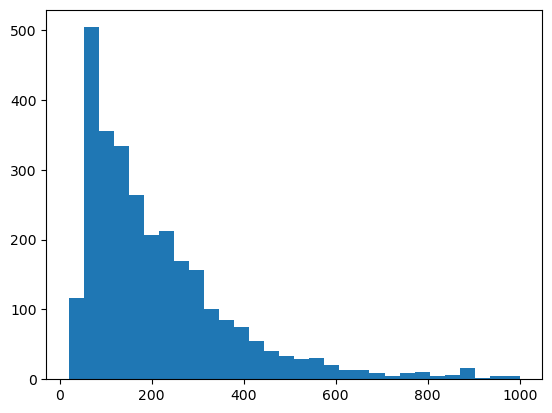

In [41]:
# method 1 for distribution of prices using histogram function from matplotlib library. 

if 'price' in SM_Airbnb_df_clean.columns:
    plt.hist(SM_Airbnb_df_clean["price"], bins=30)

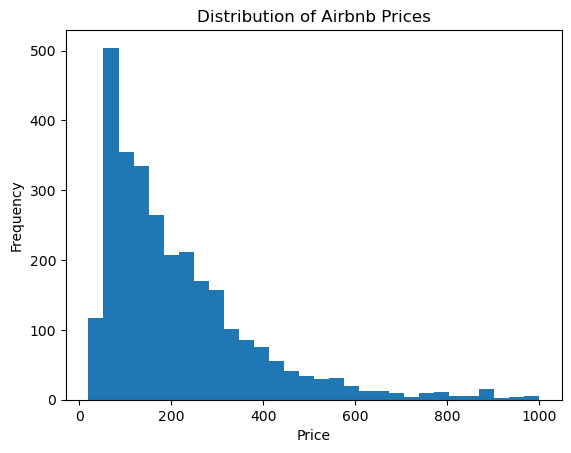

In [42]:
# method 2 for distirbution of prices using .plot()

SM_Airbnb_df_clean['price'].plot(kind='hist', bins=30)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Airbnb Prices')
plt.show()

In [ ]:
# For the price distribution, the prices with the most Airbnb hostings tend to be between $0 to $200. 

## 8) Do the room types have different average prices? 

In [44]:
if {'room_type', 'price'}.issubset(SM_Airbnb_df_clean.columns):
    room_price = SM_Airbnb_df_clean.groupby('room_type')['price'].mean().sort_values(ascending=False)

room_price

room_type
Entire home/apt    264.700944
Hotel room         187.600000
Private room        99.575211
Shared room         35.147059
Name: price, dtype: float64

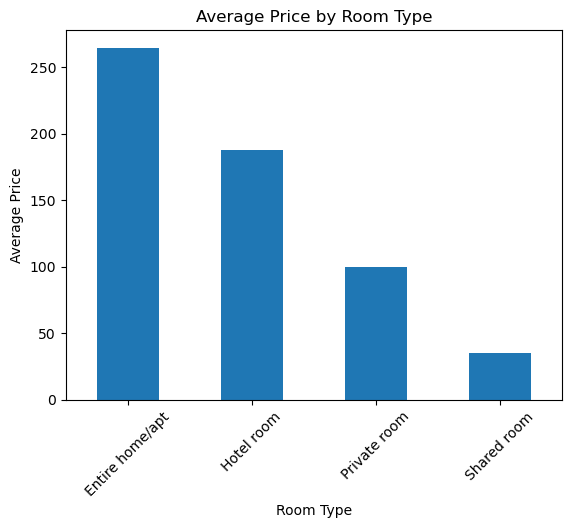

In [45]:
if {'room_type', 'price'}.issubset(SM_Airbnb_df_clean.columns):
    room_price.plot(kind='bar')
    plt.xlabel('Room Type')
    plt.ylabel('Average Price')
    plt.title('Average Price by Room Type')
    plt.xticks(rotation=45)
    plt.show()

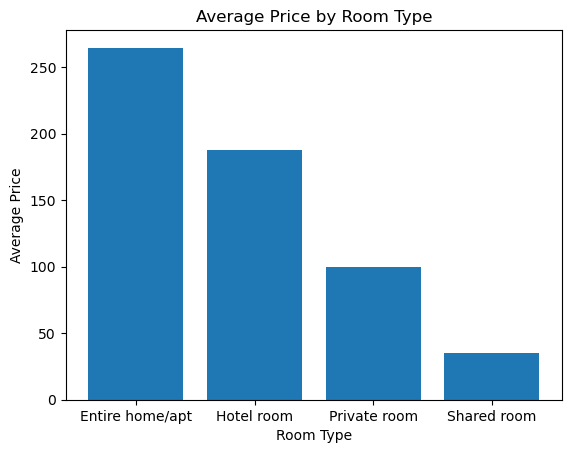

In [50]:
# alternative bar graph using matplotlib 

room_type_avg_price= SM_Airbnb_df_clean.groupby('room_type')['price'].mean()
plt.bar(room_type_avg_price.index, room_type_avg_price.values)

plt.xlabel('Room Type')
plt.ylabel('Average Price')
plt.title('Average Price by Room Type')
plt.show()

 The room types have different average prices.

## 9) Which areas are most expensive? 

In [115]:
if 'neighbourhood_group' in SM_Airbnb_df_clean.columns and SM_Airbnb_df_clean['neighbourhood_group'].notna().any():    
    area_AVGprice = SM_Airbnb_df_clean.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
elif {'neighbourhood', 'price'}.issubset(SM_Airbnb_df_clean.columns):
    area_AVGprice = SM_Airbnb_df_clean.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(10)

area_AVGprice

neighbourhood
Portola Valley          480.250000
Woodside                340.636364
Menlo Park              304.680851
Half Moon Bay           289.354839
Unincorporated Areas    281.915332
Pacifica                247.014354
Burlingame              238.287356
Redwood City            237.262963
Foster City             229.187500
Hillsborough            220.333333
Name: price, dtype: float64

The most expensive areas by looking at the average prices of each neighbourhood(top 3) are Portola Valley, Woodside, and Menlo Park. 

## 10) Is there a relationship between reviews and price? 

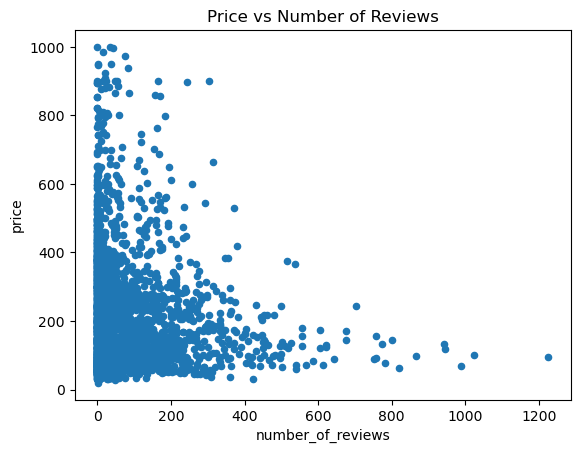

In [81]:
if {'number_of_reviews', 'price'}.issubset(SM_Airbnb_df_clean.columns):
    SM_Airbnb_df_clean.plot(kind='scatter', x='number_of_reviews', y='price')
    plt.title('Price vs Number of Reviews')
    plt.show()

The scatter plot shows a "L" shape curve, indicating a negative relationship with most of the points are densly occupying around the bottom left corner, where there are lower prices (between $0 to $400) and lower number of reviews (0 to 400). Since this relationship is not strongly linear, this explains how the number of reviews may not influence the price and might be influenced by different factors, such as the age of the posting, or frequency of the hosting. Hence, there seems to be a weak negative relationship betweeen number of reviews and price. 